In [61]:
from skimage.morphology import skeletonize
from skimage.util import invert
from skimage.filters import *
from skimage.transform import *
from skimage.exposure import histogram
from skimage import io
import numpy as np
from matplotlib import pyplot as plt
import os

In [62]:
os.chdir(r"C:\Users\JxLee\Documents\GitHub\FYP2021")
os.path.exists(r"b03-025")

True

img.shape: (90, 324)


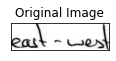

In [134]:
#INPUT IMAGE
v = r'b03-025\b03-025-00-06.png'
image = io.imread(v, as_gray=True)
img = io.imread(v, as_gray=True)

# img[: ,23: 50] += 100

plt.subplot(2,3,1),plt.imshow(img,'gray')
plt.title("Original Image")
plt.xticks([]),plt.yticks([])
print('img.shape:',img.shape)
plt.show()

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


(<Figure size 576x360 with 8 Axes>,
 array([<AxesSubplot:title={'center':'Original'}>,
        <AxesSubplot:title={'center':'Isodata'}>,
        <AxesSubplot:title={'center':'Li'}>,
        <AxesSubplot:title={'center':'Mean'}>,
        <AxesSubplot:title={'center':'Minimum'}>,
        <AxesSubplot:title={'center':'Otsu'}>,
        <AxesSubplot:title={'center':'Triangle'}>,
        <AxesSubplot:title={'center':'Yen'}>], dtype=object))

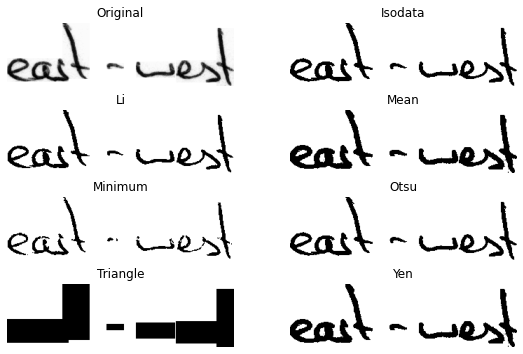

In [135]:
try_all_threshold(img,)

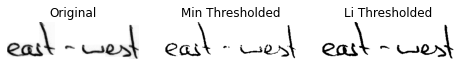

In [136]:
liThresh = threshold_li(img)
MinThresh = threshold_minimum(img)
binaryLi = img > liThresh
binaryMin = img > MinThresh

fig, axes = plt.subplots(ncols=3, figsize=(8, 2.5))
ax = axes.ravel()
ax[0] = plt.subplot(1, 3, 1)
ax[1] = plt.subplot(1, 3, 2)
ax[2] = plt.subplot(1, 3, 3, sharex=ax[0], sharey=ax[0])

ax[0].imshow(img, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(binaryMin,cmap=plt.cm.gray)
ax[1].set_title('Min Thresholded')
ax[1].axis('off')

ax[2].imshow(binaryLi, cmap=plt.cm.gray)
ax[2].set_title('Li Thresholded')
ax[2].axis('off')

plt.show()

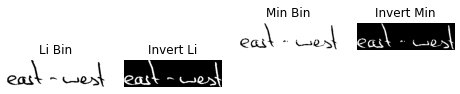

In [137]:
# Invert the horse image
invertedLi = invert(binaryLi)
invertedMin = invert(binaryMin)

fig, axes = plt.subplots(ncols=4, figsize=(8, 2.5))
ax = axes
ax[0] = plt.subplot(1, 4, 1)
ax[1] = plt.subplot(1, 4, 2)
ax[2] = plt.subplot(2, 4, 3)
ax[3] = plt.subplot(2, 4, 4, sharex=ax[0], sharey=ax[0])

ax[0].imshow(binaryLi, cmap=plt.cm.gray)
ax[0].set_title('Li Bin')
ax[0].axis('off')

ax[1].imshow(invertedLi,cmap=plt.cm.gray)
ax[1].set_title('Invert Li')
ax[1].axis('off')

ax[2].imshow(binaryMin, cmap=plt.cm.gray)
ax[2].set_title('Min Bin')
ax[2].axis('off')

ax[3].imshow(invertedMin, cmap=plt.cm.gray)
ax[3].set_title('Invert Min')
ax[3].axis('off')

plt.show()

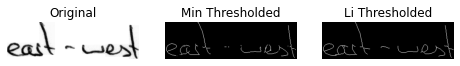

In [138]:
# Invert the horse image
skelLi = skeletonize(invertedLi)
skelMin = skeletonize(invertedMin)

fig, axes = plt.subplots(ncols=3, figsize=(8, 2.5))
ax = axes.ravel()
ax[0] = plt.subplot(1, 3, 1)
ax[1] = plt.subplot(1, 3, 2)
ax[2] = plt.subplot(1, 3, 3, sharex=ax[0], sharey=ax[0])

ax[0].imshow(img, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(skelMin,cmap=plt.cm.gray)
ax[1].set_title('Min Thresholded')
ax[1].axis('off')

ax[2].imshow(skelLi, cmap=plt.cm.gray)
ax[2].set_title('Li Thresholded')
ax[2].axis('off')

plt.show()

[]

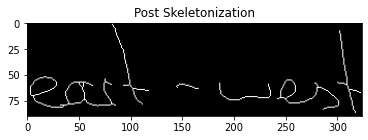

In [139]:
plt.imshow(skelLi, cmap=plt.cm.gray)
plt.title('Post Skeletonization')
plt.plot()

<h1>Auto Rotations</h1>

In [140]:
def closestToZero(x):
    closest = x[0];

    for i in x:
        num = i
        absNum = abs(num)
        absClosest = abs(closest)

        if absNum < absClosest:
            closest = num
        elif absNum == absClosest and closest < 0:
            closest = num;

    return closest

def range_subset(r1,r2):
    if not r1:
        return True
    if not r2:
        return False
    if len(r1) > 1 and r1.step % r2.step:
        return False
    return r1.start in r2 and r1[-1] in r2

[-7. 40.]
-7.0


[]

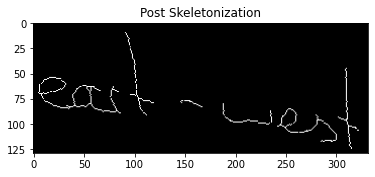

In [141]:
maxFGvalue = []
for i in range(-30,31):
    rotatedImg = rotate(skelLi,i,resize=True)
    horForegroundValue = np.sum(rotatedImg, axis=0)
    maxFGvalue.append([i,np.max(horForegroundValue)])

MFG = np.array(maxFGvalue)
a,b = np.where(MFG == np.max(MFG,axis=0)[1])
# print(a,b)
# print(MFG[a[1]][0])

# get optimal angle of rotation (close to 0)
# if a.shape[0] % 2 == 0:
#     a = np.append(a, 100)
# np.median(a)

print(MFG[a][0])
print(closestToZero(MFG[a][0]))

rotatedImg = rotate(skelLi,closestToZero(MFG[a][0]),resize=True)
plt.imshow(rotatedImg, cmap=plt.cm.gray)
plt.title('Post Skeletonization')
plt.plot()

<h1>Num of Foreground Pixel Analysis</h1>

In [142]:
#num of foreground pixels in each columns
c = np.sum(rotatedImg,axis=0)

numOfChar = 0
charFirstIndex = []
charLastIndex = []
charFirstIndexZ = []
charLastIndexZ = []
nc = np.nditer(c, flags=['f_index'])
for x in nc:
    if (x != 0 and x != 1) and (c[nc.index-1] == 0 or c[nc.index-1] == 1):
        numOfChar += 1
        charFirstIndex.append(nc.index)

    if (x !=0 and x !=1) and (c[nc.index+1] == 0 or c[nc.index+1] == 1):
        charLastIndex.append(nc.index)

    if x!= 0 and c[nc.index-1] == 0:
        charFirstIndexZ.append(nc.index)

    if x!= 0 and c[nc.index+1] == 0:
        charLastIndexZ.append(nc.index)

# print(numOfChar)

#change to numpy array: charFirstIndex and charLastIndex is the first & last index of segmented word (contains only non-zero (and non-ones))
charFirstIndex = np.asarray(charFirstIndex)
charLastIndex = np.asarray(charLastIndex)
charFirstIndexZ = np.asarray(charFirstIndexZ)
charLastIndexZ = np.asarray(charLastIndexZ)

charIndex = list(tuple(zip(charFirstIndex,charLastIndex)))

# print(charFirstIndex)
# print(charLastIndex)
# print(charFirstIndex.shape,':',charLastIndex.shape)
# print(charIndex)


In [143]:
# Potential Segmentation Columns (PSG) : tuples of PSG indices (contains only zeros (or ones))
PSG = list(zip(charLastIndex + 1,np.delete(charFirstIndex - 1,0)))
PSGZ = list(zip(charLastIndexZ + 1, np.delete(charFirstIndexZ - 1,0)))
# print(PSG)
ghj = []

#if num of foreground is 0 and are only singel column, might be noise
for x in PSGZ:
    # print(x,'=', x[1]-x[0]+1)
    if x[1]-x[0]+1 > 1:
        ghj.append(x)

# print(ghj)
PSGZ = ghj
print(PSGZ)

for x in PSG:
    for y in PSGZ:
        if range_subset(range(y[0],y[1]+1), range(x[0],x[1]+1)):
            # print(y,' is in PSG',x)
            # print(type(x))
            try:
                PSG.remove(x)
                PSG.insert(-1,y)
            except ValueError:
                pass
            
PSG.sort()
PSG
# len(PSG)
# len(charIndex)

[(87, 90), (120, 145), (168, 187), (237, 241)]


[(7, 7),
 (37, 38),
 (48, 48),
 (67, 75),
 (87, 90),
 (113, 146),
 (148, 154),
 (168, 187),
 (190, 194),
 (196, 234),
 (237, 241),
 (262, 270),
 (272, 279),
 (283, 284),
 (301, 308),
 (316, 318)]

[]

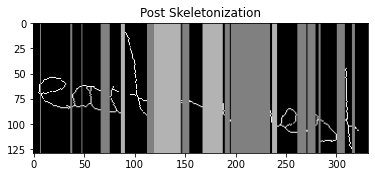

In [144]:
showSegImg = np.copy(rotatedImg)

for x in PSG:
    # print(x[0], ':', x[1])
    showSegImg[:,x[0]:x[1]+1] = .5

for x in PSGZ:
    showSegImg[:,x[0]:x[1]+1] = .7

plt.imshow(showSegImg, cmap=plt.cm.gray)
plt.title('Post Skeletonization')
plt.plot()
# print(PSG,'len',len(PSG))
# print(charIndex,'len',len(charIndex))


In [145]:
###---dont use---###
# SC = []
# first = PSG[0][0]
# for i, x in enumerate(PSG):
#     print(i,x,charIndex[i+1])
#     print('SG',charIndex[i+1][1] - charIndex[i+1][0] + 1)
#     if(charIndex[i+1][1] - charIndex[i+1][0] + 1 >= 7):
#         SC.append((first,PSG[i+1][1]))
#         first = PSG[i+2][1]

# print(SC)
# SC.pop()
##---dont use_---##


SC = []
first = PSG[0][0]
for i, x in enumerate(PSG):
    print(i,x,charIndex[i+1])
    # print('SG',charIndex[i+1][1] - charIndex[i+1][0] + 1)
    if x in PSGZ:
        SC.append(x)
    elif(charIndex[i+1][1] - charIndex[i+1][0] + 1 > 6):
        print(PSG[i])
        SC.append(PSG[i+1])
        
SC = list(dict.fromkeys(SC))#remove dup
print(SC)
# SC.pop()

    

0 (7, 7) (8, 36)
(7, 7)
1 (37, 38) (39, 47)
(37, 38)
2 (48, 48) (49, 66)
(48, 48)
3 (67, 75) (76, 84)
(67, 75)
4 (87, 90) (92, 112)
5 (113, 146) (147, 147)
6 (148, 154) (155, 155)
7 (168, 187) (188, 189)
8 (190, 194) (195, 195)
9 (196, 234) (235, 236)
10 (237, 241) (245, 261)
11 (262, 270) (271, 271)
12 (272, 279) (280, 282)
13 (283, 284) (285, 300)
(283, 284)
14 (301, 308) (309, 315)
(301, 308)
15 (316, 318) (319, 319)
[(37, 38), (48, 48), (67, 75), (87, 90), (168, 187), (237, 241), (301, 308), (316, 318)]


[]

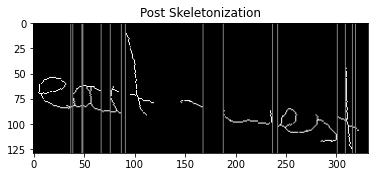

In [146]:
showSegImg2 = np.copy(rotatedImg)

for x in SC:
    # print(x[0], ':', x[1])
    showSegImg2[:,x[0]] = .5
    showSegImg2[:,x[1]+1] = .5

plt.imshow(showSegImg2, cmap=plt.cm.gray)
plt.title('Post Skeletonization')
plt.plot()

[(37, 38), (48, 48), (67, 75), (87, 90), (168, 187), (237, 241), (301, 308), (316, 318)]
37 : 38
48 : 48
67 : 75
87 : 90
168 : 187
237 : 241
301 : 308
316 : 318


[]

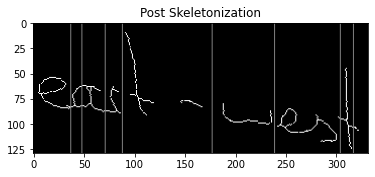

In [150]:
showSCout = np.copy(rotatedImg)
print(SC)
SegCol = []
for x in SC:
    print(x[0], ':', x[1])
    b = [*range(x[0],x[1]+1)]
    # print(np.median(b))
    SegCol.append(int(np.median(b)))
    showSCout[:,int(np.median(b))] = .5
    # showSCout[:,int(np.mean(c[x[0]:x[1]]))] = .5
    # print(np.median(c[x[0]:x[1]+1]))
    

plt.imshow(showSCout, cmap=plt.cm.gray)
plt.title('Post Skeletonization')
plt.plot()

In [152]:
img[SegCol]

IndexError: index 177 is out of bounds for axis 0 with size 90